#**APRENDIZADO PROFUNDO - ATIVIDADE DE PROGRAMAÇÃO 1**

#***Carlos Murilo da SIlva Valadares***

##**PARTE 1 -  Construção e treinamento da Rede Neural com dataset MNIST, para posterior comparação**

In [1]:
import numpy as np
import tensorflow as tf # biblioteca de redes neurais de aprendizado profundo

from matplotlib import pyplot as plt
from sklearn.model_selection import KFold


In [2]:
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
# Conv2D é a camada convolucional
# MaxPooling2d é a camada de pooling
# Dense é a camada de neuronios totalmente conectados
# Flatten transforma a imagem em um único vetor
from tensorflow.keras.optimizers import Adam
print("Bibliotecas instaladas!!!")

Bibliotecas instaladas!!!


# Importando dados

Aqui usaremos o dataset MNIST (https://en.wikipedia.org/wiki/MNIST_database), que consiste em imagens de dígitos de 0 a 9 escritos manualmente. As imagens desse dataset são na escala grayscale (possuindo um único canal), tendo dimensões 28 x 28 x 1


In [3]:
# carregando dataset
(trainX, trainY), (testX, testY) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Faremos algumas adequações para que os dados sejam usados no modelo de CNN. Basicamente, colocamos os valores dos pixels em uma escala de 0 a 1, visto que os valores originais dos pixels das imagens correspondem a uma escala de 0 a 255. Também transformamos nossa variável alvo em uma codificação one-hos

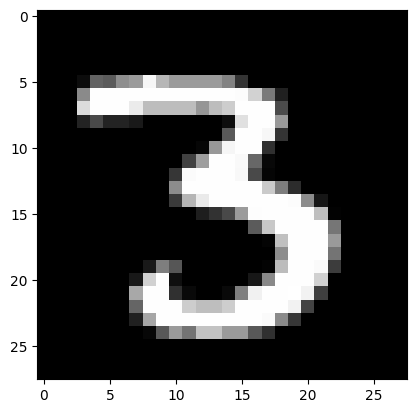

In [4]:
plt.imshow(trainX[12], cmap='gray');

In [5]:
# fazendo um reshape no dataset para ter um único canal
trainX = trainX.reshape((trainX.shape[0], 28, 28, 1))
testX = testX.reshape((testX.shape[0], 28, 28, 1))

# Convertendo valores dos pixels em float
trainX = trainX.astype('float32')
testX = testX.astype('float32')

# normalização para escala [0-1]
trainX = trainX / 255.0
testX = testX / 255.0

# transformando a variável alvo (target) para uma codificação one hot
trainY = to_categorical(trainY)
testY = to_categorical(testY)

# Construindo o modelo

Estrutura do modelo:
* Uma única camada convolucional com 32 filtros de tamanho 3 x 3 e função de ativação ReLU
* Camada MaxPooling para redução de dimensionalidade
* Transformação do resultado em um vetor
* Camada totalmente conectada com 100 neurônios e função de ativação ReLU
* Camada de saída softmax para estimar a probabilidade da entrada da rede pertencer a cada uma das 10 classes (dígitos 0 a 9)


Para treinamento do modelo, usaremos o algoritmo de otimização clássico do gradiente descendente estocástico (SDG). Nossa principal métrica de desempenho será a acurácia.

In [6]:
# definindo modelo, com as camadas adicionadas em sequência
def define_model():
  model = Sequential()
  model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1))) # 32 filros, 3x3, função de ativação relu
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2))) # A diminuir a amostragem
  model.add(Flatten()) # transformando em vetor
  model.add(Dense(100, activation='relu'))
  model.add(Dense(10, activation='softmax'))


  # compilando modelo
  opt = Adam(learning_rate=0.001) # Otimizador Adam.
  model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy']) # Função de erro loss
  return model


# Treinamento do modelo

O treinamento será realizado usando o método da validação cruzada k-partições (k-fold) com k=5. Tal validação cruzada faz a divisão dos dados em 5 grupos de tamanho igual, sendo realizadas 5 treinamentos distintos. A cada treinamento, 4 grupos de dados são utilizados para treinar o modelo e o grupo remanescente é usado para teste do desempenho do modelo treinado.



In [7]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9276 - loss: 0.2370 - val_accuracy: 0.9794 - val_loss: 0.0703
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9868 - loss: 0.0383 - val_accuracy: 0.9826 - val_loss: 0.0685
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9927 - loss: 0.0219 - val_accuracy: 0.9737 - val_loss: 0.1097
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9952 - loss: 0.0157 - val_accuracy: 0.9818 - val_loss: 0.0903
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9938 - loss: 0.0159 - val_accuracy: 0.9760 - val_loss: 0.1170
> 98.258
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9176 - loss: 0.2717 - val_accuracy: 0.9739 - val_loss: 0.0829
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9864 - loss: 0.0435 - val_accuracy: 0.9793 - val_loss: 0.0693
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9914 - loss: 

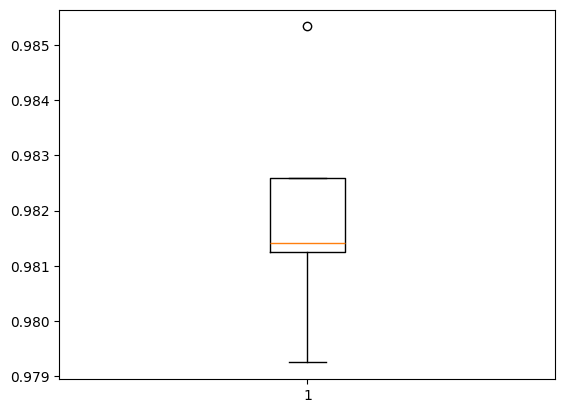

In [8]:
scores = []
histories = []

# definindo a validação k-fold
kfold = KFold(5, shuffle=True, random_state=1)

# loop para as k-folds (cada fold usa subconjuntos de treino e teste diferentes)
for train_ix, test_ix in kfold.split(trainX):

  model = define_model()

  # recorta dados de acordo com índices da k-fold
  train_data, train_target, val_data, val_target = trainX[train_ix], trainY[train_ix], trainX[test_ix], trainY[test_ix]

  # treinamento do modelo
  history = model.fit(train_data, train_target,
                      epochs=10, batch_size=32,
                      validation_data=(val_data, val_target),
                      verbose=1, callbacks=[callback])

  # desempenho do modelo
  _, acc = model.evaluate(val_data, val_target, verbose=0)
  print('> %.3f' % (acc * 100.0))

  # armazena resultados de cada modelo treinado dentro da k-fold
  scores.append(acc)
  histories.append(history)

print('Acurácia: média=%.3f desvio=%.3f' % (np.mean(scores)*100, np.std(scores)*100))
plt.boxplot(scores)
plt.show()

# Testando modelo no conjunto de teste

Agora avaliaremos o desempenho do modelo em dados do conjunto de teste separado nas etapas iniciais deste exercício
* Abaixo temos a primeira imagem do conjunto de teste

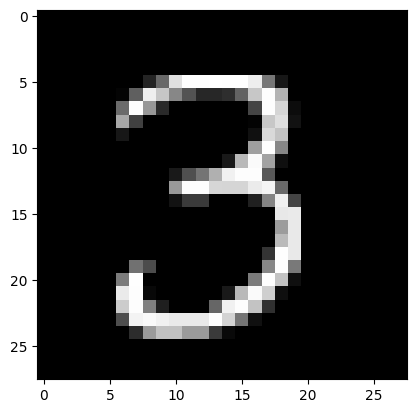

In [9]:
plt.imshow(testX[334,:,:,0], cmap='gray');

Usaremos o último modelo treinado na validação cruzada k-fold para classificar qual número temos na imagem (podemos também salvar cada um dos modelos intermediários e usar o que apresentar maior performance ou fazer um comitê de votação com os 5 modelos disponíveis)

* temos que fazer uma expansão de dimensão para que nossa imagem tenha um formato 1 x 28 x 28 x 1. Isso é necessário pois treinamos nosso modelo usando mini conjuntos de imagens (como nosso batch size era de 32, o formato passado para o modelo a cada passo de treinamento era 32 x 28 x 28 x 1)

In [10]:
np.argmax(model.predict(np.expand_dims(testX[334], axis=0)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step


np.int64(3)

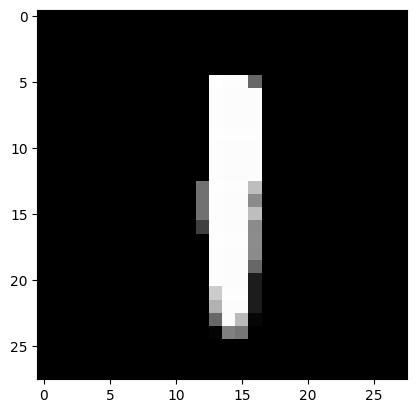

In [11]:
plt.imshow(testX[345,:,:,0], cmap='gray');

In [12]:
np.argmax(model.predict(np.expand_dims(testX[567], axis=0)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


np.int64(0)

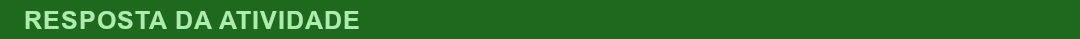

#***Resposta para a parte 1***
##***- Para a amostra de imagens estudadas e o tipo de rede utilizada, bem como sue modelo de treinamento, a acurácia resultante foi alta, com média=97.903 desvio=0.311. A rede treinada levou 132ms para reconhecer uma amostra oferecida. A acurácia máxima obtida em uma das épocas superou 0.982.***

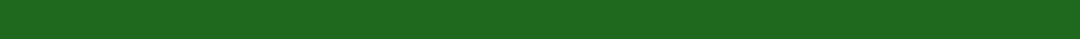





---



---



---



---



#**APRENDIZADO PROFUNDO - ATIVIDADE DE PROGRAMAÇÃO 1**

##**PARTE 2 -  Rede Neural com dataset cifar10, com apenas uma camada Conv2D e uma camada MaxPooling2D, para comparação com a rede anterior**

**Repita o exemplo Image_classification_CNN usando o dataset CIFAR-10 (https://www.tensorflow.org/datasets/catalog/cifar10), também disponível no Tensorflow. As imagens agora tem a forma 32 x 32 x 3, sendo necessário fazer ajustes na rede para esse caso. Recomendado executar usando o recurso de GPU do Colab agilizar os treinamentos das redes.**

O conjunto de dados CIFAR-10 (Canadian Institute For Advanced Research) é uma coleção de imagens amplamente utilizada para algoritmos de aprendizagem automática e visão por computador. Foi desenvolvido por investigadores do instituto CIFAR e é composto por 60 000 imagens a cores 32x32 em 10 classes diferentes.

Amostras da biblioteca CIFAR-10:
airplane (avião:0), automobile (automóvel:1), bird (pássaro:2), cat (gato:3), deer (cervo:4), dog (cachorro:5), frog (sapo:6), horse (cavalo:7), ship (navio:8), truck (caminhão:9)

**Houve muita diferença no desempenho da rede treinada quando comparado ao exemplo?**




In [13]:
import numpy as np
import tensorflow as tf # biblioteca de redes neurais profundas

from matplotlib import pyplot as plt
from sklearn.model_selection import KFold
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
# Conv2D é a camada convolucional
# MaxPooling2d é a camada de pooling
# Dense é a camada de neuronios totalmente conectados
# Flatten transforma a imagem em um único vetor
from tensorflow.keras.optimizers import Adam
print("Bibliotecas instaladas!!!")

Bibliotecas instaladas!!!


# Importando dados

***Biblioteca cifar10:
O conjunto de dados CIFAR-10 consiste em 60.000 imagens coloridas 32x32 em 10 classes, com 6.000 imagens por classe. Existem 50.000 imagens de treinamento e 10.000 imagens de teste.***

In [14]:
# carregando dataset
(trainX, trainY), (testX, testY) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Faremos algumas adequações para que os dados sejam usados no modelo de CNN. Basicamente, colocamos os valores dos pixels em uma escala de 0 a 1, visto que os valores originais dos pixels das imagens correspondem a uma escala de 0 a 255. Também transformamos nossa variável alvo em uma codificação one-hos

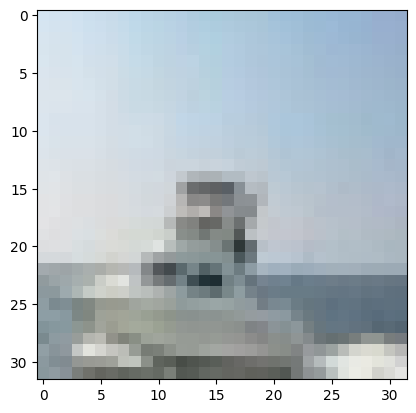

In [15]:
plt.imshow(trainX[100], cmap='gray');

In [16]:
# fazendo um reshape no dataset para ter um único canal
trainX = trainX.reshape((trainX.shape[0], 32, 32, 3))
testX = testX.reshape((testX.shape[0], 32, 32, 3))

# Convertendo valores dos pixels em float
trainX = trainX.astype('float32')
testX = testX.astype('float32')

# normalização para escala [0-1]
trainX = trainX / 255.0
testX = testX / 255.0

# transformando a variável alvo (target) para uma codificação one hot
# A codificação one hot transforma cada elemento em um vetor, para que não seja lido como número
trainY = to_categorical(trainY)
testY = to_categorical(testY)

# Construindo o modelo

O modelo usado será bem simples:
* Uma única camada convolucional com 64 filtros de tamanho 3 x 3 e função de ativação ReLU
* Camada MaxPooling para redução de dimensionalidade
* Transformação do resultado em um vetor
* Camada totalmente conectada com 100 neurônios e função de ativação ReLU
* Camada de saída softmax para estimar a probabilidade da entrada da rede pertencer a cada uma das 10 classes (dígitos 0 a 9)


Para treinamento do modelo, usaremos o algoritmo de otimização clássico do gradiente descendente estocástico (SDG), com a função objetiva como a entropia cruzada categórica. Nossa principal métrica de desempenho será a acurácia

In [17]:
# definindo modelo
def define_model():
  model = Sequential()
  model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(32,32, 3))) # 32 filros, 3x3, função de ativação relu
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2))) # A diminuir a amostragem
  model.add(Flatten()) # transformando em vetor
  model.add(Dense(100, activation='relu'))
  model.add(Dense(10, activation='softmax'))

# https://keras.io/api/layers/regularization_layers/dropout/ ....> PARA USAR O DROPOUT

  # compilando modelo
  opt = Adam(learning_rate=0.001)
  model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
  return model


# Treinamento do modelo

O treinamento será realizado usando o método da validação cruzada k-partições (k-fold) com k=5. Tal validação cruzada faz a divisão dos dados em 5 grupos de tamanho igual, sendo realizadas 5 treinamentos distintos. A cada treinamento, 4 grupos de dados são utilizados para treinar o modelo e o grupo remanescente é usado para teste do desempenho do modelo treinado.



In [18]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4612 - loss: 1.5484 - val_accuracy: 0.3679 - val_loss: 2.0843
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6422 - loss: 1.0086 - val_accuracy: 0.6032 - val_loss: 1.1570
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7284 - loss: 0.7807 - val_accuracy: 0.6016 - val_loss: 1.2306
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7965 - loss: 0.5894 - val_accuracy: 0.6122 - val_loss: 1.3201
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8536 - loss: 0.4298 - val_accuracy: 0.6009 - val_loss: 1.5532
> 60.320
Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4491 - loss: 1.6064 - val_accuracy: 0.5454 - val_loss: 1.2757
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6465 - loss: 0.9985 - val_accuracy: 0.5973 - val_loss: 1.2112
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7288 - loss: 

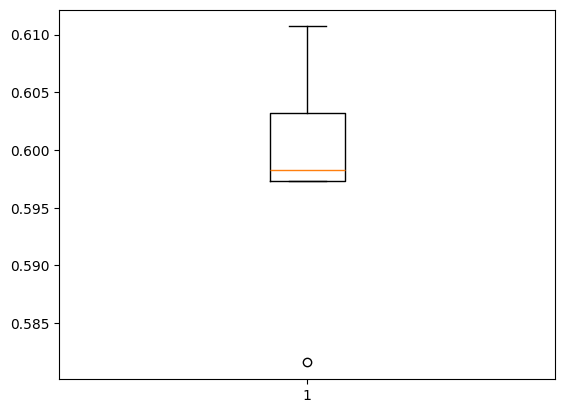

In [19]:
scores = []
histories = []

# definindo a validação k-fold
kfold = KFold(5, shuffle=True, random_state=1)

# loop para as k-folds (cada fold usa subconjuntos de treino e teste diferentes)
for train_ix, test_ix in kfold.split(trainX):

  model = define_model()

  # recorta dados de acordo com índices da k-fold
  train_data, train_target, val_data, val_target = trainX[train_ix], trainY[train_ix], trainX[test_ix], trainY[test_ix]

  # treinamento do modelo
  history = model.fit(train_data, train_target,
                      epochs=10, batch_size=32,
                      validation_data=(val_data, val_target),
                      verbose=1, callbacks=[callback])

  # desempenho do modelo
  _, acc = model.evaluate(val_data, val_target, verbose=0)
  print('> %.3f' % (acc * 100.0))

  # armazena resultados de cada modelo treinado dentro da k-fold
  scores.append(acc)
  histories.append(history)

print('Acurácia: média=%.3f desvio=%.3f' % (np.mean(scores)*100, np.std(scores)*100))
plt.boxplot(scores)
plt.show()

# Testando modelo no conjunto de teste

Agora avaliaremos o desempenho do modelo em dados do conjunto de teste separado nas etapas iniciais deste exercício
* Abaixo temos a primeira imagem do conjunto de teste

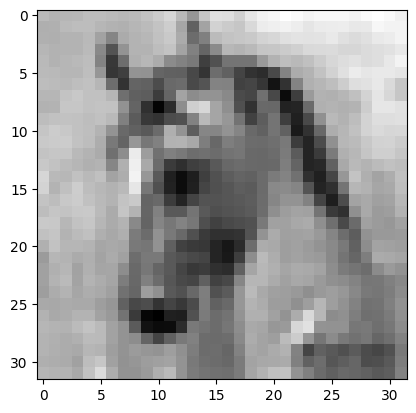

In [20]:
plt.imshow(testX[210,:,:,0], cmap='gray');

Usaremos o último modelo treinado na validação cruzada k-fold para classificar qual número temos na imagem (podemos também salvar cada um dos modelos intermediários e usar o que apresentar maior performance ou fazer um comitê de votação com os 5 modelos disponíveis)

* temos que fazer uma expansão de dimensão para que nossa imagem tenha um formato 1 x 28 x 28 x 1. Isso é necessário pois treinamos nosso modelo usando mini conjuntos de imagens (como nosso batch size era de 32, o formato passado para o modelo a cada passo de treinamento era 32 x 28 x 28 x 1)

In [21]:
np.argmax(model.predict(np.expand_dims(testX[210], axis=0)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step


np.int64(3)

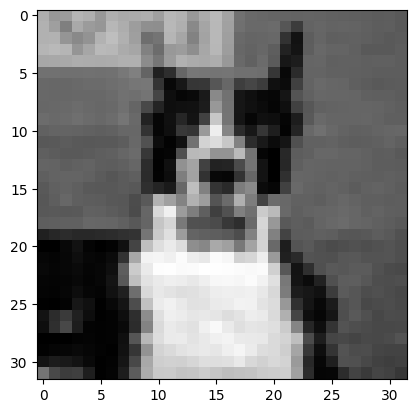

In [22]:
plt.imshow(testX[345,:,:,0], cmap='gray');

In [23]:
np.argmax(model.predict(np.expand_dims(testX[345], axis=0)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


np.int64(5)

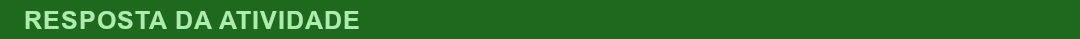

#***Resposta para a parte 2***
##***- Os valores obtidos no treinamento desta rede foram bastante diferentes do caso anterior. O dataset cifar10, que contém imagens maiores do que as amostras enteriores, foi submetido a uma rede neural com apenas uma camada Conv2D e uma camada MaxPooling2D.***

##***- Para a amostra de imagens estudadas e o tipo de rede utilizada, bem como sue modelo de treinamento, a acurácia resultante foi menor que no caso das amostras anteriores, de média=55.498 desvio=5.821. O valor da acurácia média foi bem inferior ao anterior e o desvio padrão foi significativamente mais alto. Apesar destes valores, a rede levou somente 24ms paraclassificar uma imagem que lhe foi apresentada, valor bem menor que na rede anterior. ***

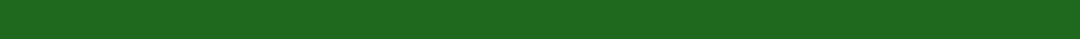



#**APRENDIZADO PROFUNDO - ATIVIDADE DE PROGRAMAÇÃO 1**

##**PARTE 3 -  Rede Neural com dataset cifar10, com adição de dois blocos de camadas Conv2D (64 filtros 3x3 - relu) + MaxPooling (2 x 2) antes da camada Flatten**

**Experimente adicionar mais dois blocos de camadas Conv2D (64 filtros 3x3 - relu) + MaxPooling (2 x 2) antes da camada Flatten e compare os resultados.**

In [24]:
# carregando dataset
(trainX, trainY), (testX, testY) = cifar10.load_data()

In [25]:
# fazendo um reshape no dataset para ter um único canal
trainX = trainX.reshape((trainX.shape[0], 32, 32, 3))
testX = testX.reshape((testX.shape[0], 32, 32, 3))

# Convertendo valores dos pixels em float
trainX = trainX.astype('float32')
testX = testX.astype('float32')

# normalização para escala [0-1]
trainX = trainX / 255.0
testX = testX / 255.0

# transformando a variável alvo (target) para uma codificação one hot
# A codificação one hot transforma cada elemento em um vetor, para que não seja lido como número
trainY = to_categorical(trainY)
testY = to_categorical(testY)

**Construindo o modelo, com duas camadas Conv2D e MaxPooling2D**

In [26]:
# definindo modelo
def define_model():
  model = Sequential()
  model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(32,32, 3))) # 32 filros, 3x3, função de ativação relu
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2))) # A diminuir a amostragem
  model.add(Conv2D(64, (3, 3), activation='relu')) # 32 filros, 3x3, função de ativação relu
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2))) # A diminuir a amostragem
  model.add(Flatten()) # transformando em vetor
  model.add(Dense(100, activation='relu'))
  model.add(Dense(10, activation='softmax'))

# https://keras.io/api/layers/regularization_layers/dropout/ ....> PARA USAR O DROPOUT

  # compilando modelo
  opt = Adam(learning_rate=0.001)
  model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
  return model


TREINANDO O MODELO

In [27]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.4332 - loss: 1.6328 - val_accuracy: 0.5056 - val_loss: 1.3959
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6359 - loss: 1.0304 - val_accuracy: 0.5434 - val_loss: 1.3946
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7051 - loss: 0.8386 - val_accuracy: 0.6528 - val_loss: 1.0048
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7632 - loss: 0.6714 - val_accuracy: 0.6139 - val_loss: 1.2512
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8021 - loss: 0.5663 - val_accuracy: 0.6588 - val_loss: 1.0263
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8432 - loss: 0.4488 - val_accuracy: 0.6537 - val_loss: 1.2547
> 65.280
Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.4461 - loss: 1.6151 - val_accuracy: 0.4813 - val_loss: 1.5415
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6446 - loss

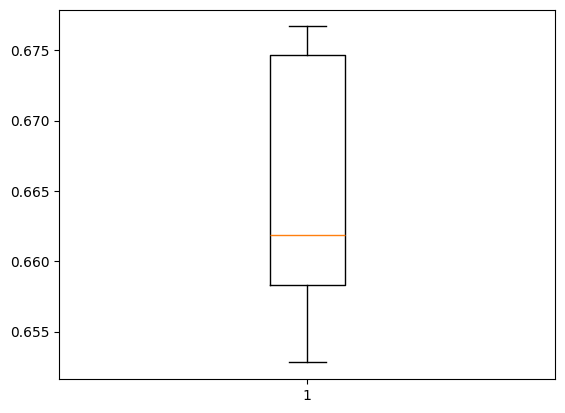

In [28]:
scores = []
histories = []

# definindo a validação k-fold
kfold = KFold(5, shuffle=True, random_state=1)

# loop para as k-folds (cada fold usa subconjuntos de treino e teste diferentes)
for train_ix, test_ix in kfold.split(trainX):

  model = define_model()

  # recorta dados de acordo com índices da k-fold
  train_data, train_target, val_data, val_target = trainX[train_ix], trainY[train_ix], trainX[test_ix], trainY[test_ix]

  # treinamento do modelo
  history = model.fit(train_data, train_target,
                      epochs=10, batch_size=32,
                      validation_data=(val_data, val_target),
                      verbose=1, callbacks=[callback])

  # desempenho do modelo
  _, acc = model.evaluate(val_data, val_target, verbose=0)
  print('> %.3f' % (acc * 100.0))

  # armazena resultados de cada modelo treinado dentro da k-fold
  scores.append(acc)
  histories.append(history)

print('Acurácia: média=%.3f desvio=%.3f' % (np.mean(scores)*100, np.std(scores)*100))
plt.boxplot(scores)
plt.show()

# Testando modelo no conjunto de teste

Agora avaliaremos o desempenho do modelo em dados do conjunto de teste separado nas etapas iniciais deste exercício
* Abaixo temos a primeira imagem do conjunto de teste

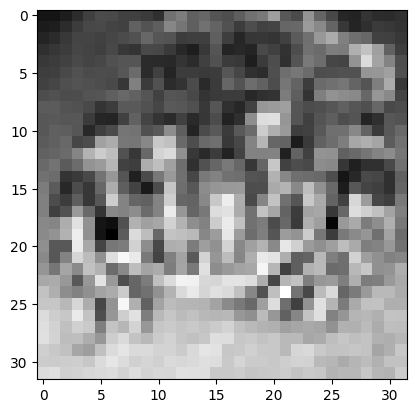

In [29]:
plt.imshow(testX[1009,:,:,0], cmap='gray');

Realizar predições

In [30]:
np.argmax(model.predict(np.expand_dims(testX[100], axis=0)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step


np.int64(4)

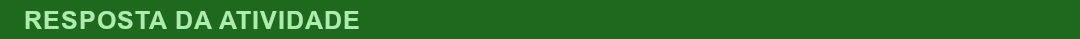

#***Resposta para a parte 3***

##**- Rede Neural com dataset cifar10, com adição de dois blocos de camadas Conv2D (64 filtros 3x3, relu) + MaxPooling (2 x 2) antes da camada Flatten**

##***- Para a amostra de imagens estudadas e o tipo de rede utilizada, bem como sue modelo de treinamento, a acurácia resultante foi ligeiramente menor que no caso anterior (média de 55.498), resultando em média=55.306 desvio=8.685. O desvio padrão almentou em relação à rede anterior.***

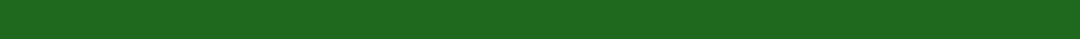



##**PARTE 4 -  Rede Neural com dataset cifar10, e seguindo o modelo modificado no item anterior, experimente adicionar um Dropout de 20% após cada camada MaxPooling. Comente os resultados obtidos.**

In [31]:
# definindo modelo
def define_model():
  model = Sequential()
  model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(32,32, 3))) # 32 filtros, 3x3, função de ativação relu
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2))) # A diminuir a amostragem
  model.add(Conv2D(64, (3, 3), activation='relu')) # 32 filros, 3x3, função de ativação relu
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2))) # A diminuir a amostragem
  model.add(Dropout(0.2)) # Adição da camada de Dropout de 20%
  model.add(Flatten()) # transformando em vetor
  model.add(Dense(100, activation='relu'))
  model.add(Dense(10, activation='softmax'))

# https://keras.io/api/layers/regularization_layers/dropout/ ....> PARA USAR O DROPOUT

  # compilando modelo
  opt = Adam(learning_rate=0.001)
  model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
  return model


# Treinando o modelo

In [32]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [ ]:
scores = []
histories = []

# definindo a validação k-fold
kfold = KFold(5, shuffle=True, random_state=1)

# loop para as k-folds (cada fold usa subconjuntos de treino e teste diferentes)
for train_ix, test_ix in kfold.split(trainX):

  model = define_model()

  # recorta dados de acordo com índices da k-fold
  train_data, train_target, val_data, val_target = trainX[train_ix], trainY[train_ix], trainX[test_ix], trainY[test_ix]

  # treinamento do modelo
  history = model.fit(train_data, train_target,
                      epochs=10, batch_size=32,
                      validation_data=(val_data, val_target),
                      verbose=1, callbacks=[callback])

  # desempenho do modelo
  _, acc = model.evaluate(val_data, val_target, verbose=0)
  print('> %.3f' % (acc * 100.0))

  # armazena resultados de cada modelo treinado dentro da k-fold
  scores.append(acc)
  histories.append(history)

print('Acurácia: média=%.3f desvio=%.3f' % (np.mean(scores)*100, np.std(scores)*100))
plt.boxplot(scores)
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4224 - loss: 1.6776 - val_accuracy: 0.4700 - val_loss: 1.6239
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6279 - loss: 1.0578 - val_accuracy: 0.6065 - val_loss: 1.0972
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6906 - loss: 0.8743 - val_accuracy: 0.6595 - val_loss: 0.9635
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7339 - loss: 0.7543 - val_accuracy: 0.6659 - val_loss: 0.9696
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7706 - loss: 0.6562 - val_accuracy: 0.6955 - val_loss: 0.9025
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7985 - loss: 0.5765 - val_accuracy: 0.6551 - val_loss: 1.0148
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8229 - loss: 0.5044 - val_accuracy: 0.6536 - val_loss: 1.0309
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8373 - loss: 0.4626 -

# Exemplo de imagem do conjunto de teste

In [ ]:
plt.imshow(testX[1009,:,:,0], cmap='gray');

Realização de predições

In [ ]:
np.argmax(model.predict(np.expand_dims(testX[100], axis=0)))

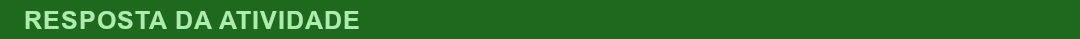

#***Resposta para a parte 4***

##**- Rede Neural com dataset cifar10, e seguindo o modelo modificado no item anterior, com adição de um Dropout de 20% após cada camada MaxPooling. Comentanto do resultados obtidos.***

##***- Para a amostra de imagens estudadas e o tipo de rede utilizada, bem como sue modelo de treinamento, a acurácia resultante foi um pouco maior que no caso anterior, resultando em acurácia com média=53.842 desvio=9.801. A adição da camada de Dropout parece ter deixado a classificação mais lenta. Entretanto, foram gastos 72ms/step para a classificação de uma imagem, o tempo inferior às redes anteriores. A configuração atual foi mais lenta em seu treinamento, mas bastante eficiente na classificação de imagens no teste da rede.**

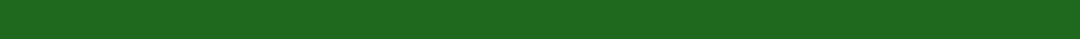

